# Indices Latlon Demo

Demonstrates `indices_latlon`, which runs the complete shelterbelts pipeline for any
lat/lon location by auto-downloading all required data:

- **Canopy height** — Meta/Tolan global 1 m CHM, binarised at `height_threshold` and
  average-resampled to 10 m to give percent cover
- **ESA WorldCover** — provides the 10 m reference grid and land-use categories
- **Terrain tiles** — MapZen elevation used to derive gullies and ridge lines
- **OpenStreetMap roads** — road network for the region of interest
- **BARRA wind** — only downloaded when `wind_method` is set

In [1]:
from shelterbelts.indices.all_indices import indices_latlon
from shelterbelts.indices.shelter_metrics import linear_categories_cmap, linear_categories_labels
from shelterbelts.utils.visualisation import visualise_categories, visualise_categories_sidebyside

# Default location: Milgadara, NSW, Australia
lat, lon, buffer = -34.389, 148.469, 0.01  # distance in degrees in each direction, so 0.01 is ~2km x 2km

## Default Parameters
* Note this may take a while (~10 mins) to run the first time at any given location since it needs to download a ~60MB tif file.

In [2]:
%%time
ds, df = indices_latlon(lat, lon, buffer, debug=True)

Working on 0/1: 3112302110
Merging 1 tiles
Saved: ./-34.389_148.469_canopy_height.tif
Saved: ./-34.389_148.469_canopy_height.png
Starting terrain_tiles.py
Downloaded ./-34.389_148.469_terrain_original.tif
Saved ./-34.389_148.469_terrain.tif
Saved: ./-34.389_148.469_gullies.tif
Saved: ./-34.389_148.469_ridges.tif
Saved: ./-34.389_148.469_gullies_and_ridges.png
Saved: ./-34.389_148.469_gullies.tif
Saved: ./-34.389_148.469_roads.gpkg
Saved: ./-34.389_148.469_roads.tif
Saved: ./-34.389_148.469_tree_categories.tif
Saved: ./-34.389_148.469_tree_categories.png
Saved: ./-34.389_148.469_shelter_categories.tif
Saved: ./-34.389_148.469_shelter_densities.tif
Saved: ./-34.389_148.469_shelter_categories.png
Saved: ./-34.389_148.469_cover_categories.tif
Saved: ./-34.389_148.469_cover_categories.png
Saved: ./-34.389_148.469_buffer_categories.tif
Saved: ./-34.389_148.469_buffer_categories.png
Saved: ./-34.389_148.469_assigned_labels.tif
Saved: ./-34.389_148.469_ellipse_outline_raster.tif
Saved: ./-34.3

In [3]:
df.head()

,label,ellipse_length,ellipse_width,ellipse len/width,perimeter,area,orientation_degrees,skeleton_width,skeleton_length,skeleton len/width,category_id,category_name
0,2,40.724160,7.775171,5.237719,99.698485,159.0,-80.906316,5.362376,33,6.153988,15.0,Trees in Gullies
1,3,10.924454,3.478613,3.140462,20.692388,24.0,-49.740920,2.428571,7,2.882353,15.0,Trees in Gullies
2,5,9.412281,4.697505,2.003677,19.449747,21.0,79.250164,3.758062,8,2.128757,15.0,Trees in Gullies
3,6,16.227674,8.797072,1.844668,44.591883,102.0,80.920311,8.415858,12,1.425880,15.0,Trees in Gullies
4,7,5.617790,4.712658,1.192064,14.242641,21.0,-38.952621,3.103553,4,1.288845,15.0,Trees in Gullies


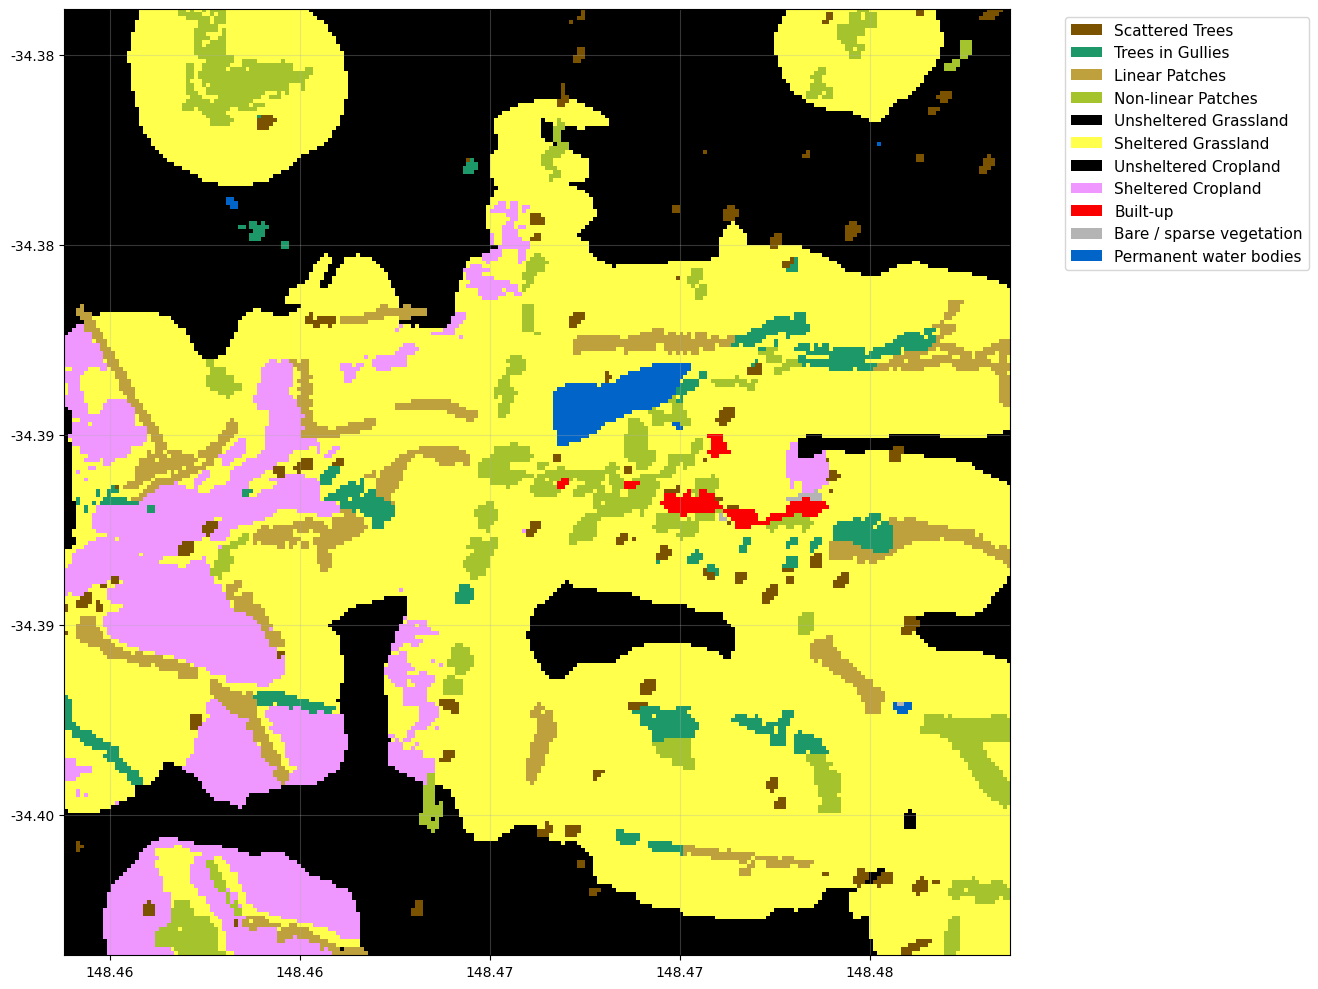

In [4]:
visualise_categories(
    ds['linear_categories'],
    colormap=linear_categories_cmap,
    labels=linear_categories_labels
)

## Changing the buffer

The `buffer` parameter sets the half-width of the region of interest in degrees
(~1° latitude ≈ 111 km). Larger buffers take longer to run.

Working on 0/1: 3112302110
Merging 1 tiles
Saved: ./buffer_medium_gullies.tif
Saved: ./buffer_medium_linear_categories.tif
Working on 0/1: 3112302110
Merging 1 tiles
Saved: ./buffer_large_gullies.tif
Saved: ./buffer_large_linear_categories.tif


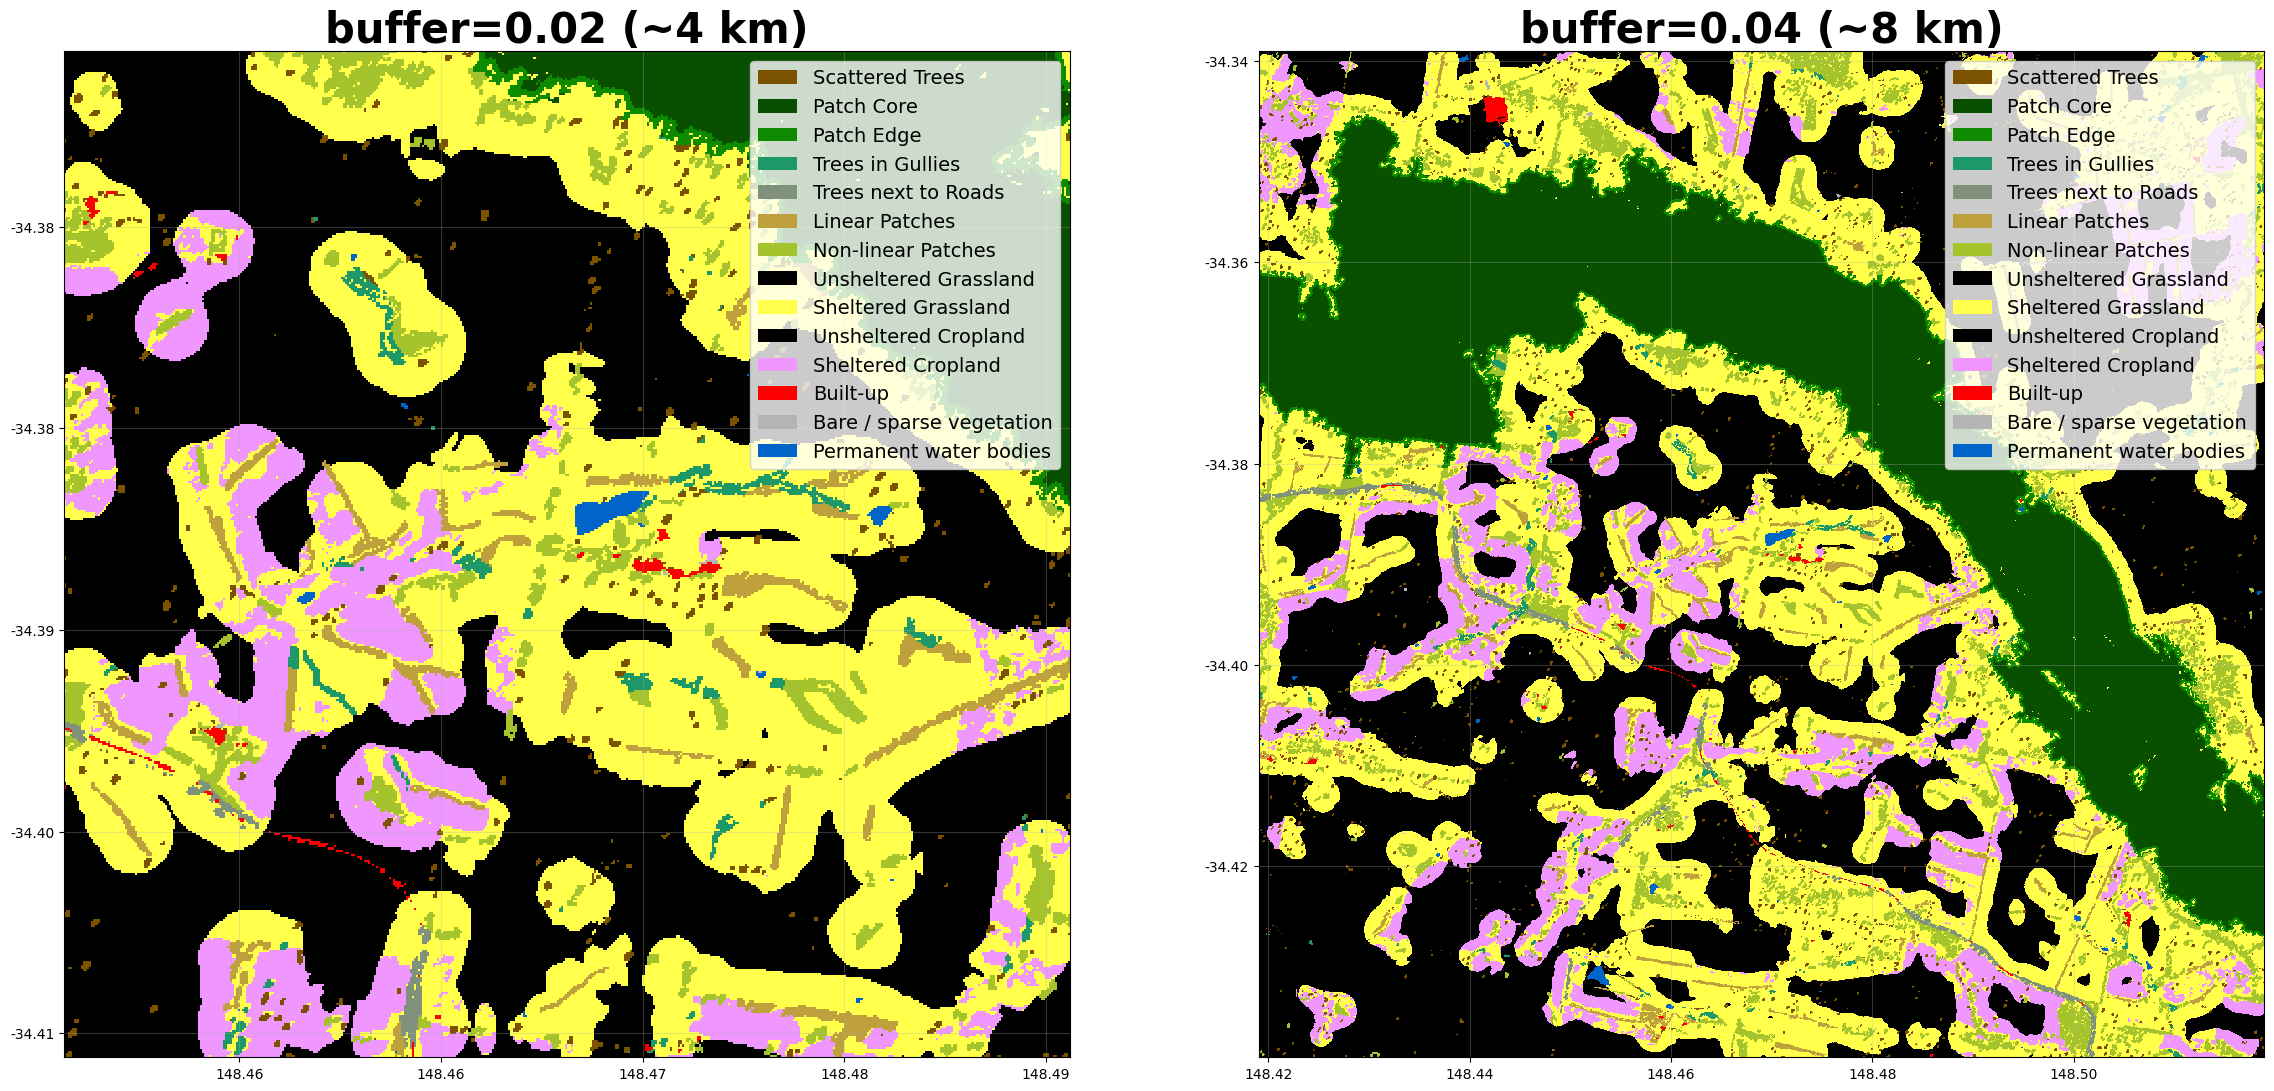

CPU times: user 2min 33s, sys: 16.6 s, total: 2min 50s
Wall time: 3min


In [5]:
%%time
ds1, _ = indices_latlon(lat, lon, buffer=0.02, stub='buffer_medium')
ds2, _ = indices_latlon(lat, lon, buffer=0.05, stub='buffer_large')
visualise_categories_sidebyside(
    ds1['linear_categories'], ds2['linear_categories'],
    colormap=linear_categories_cmap, labels=linear_categories_labels,
    title1="buffer=0.02 (~4 km)", title2="buffer=0.04 (~8 km)"
)

## Changing the height_threshold

The `height_threshold` (metres) controls which pixels in the 1 m canopy height model
are classified as trees or not.

Working on 0/1: 3112302110
Merging 1 tiles
Saved: ./height1_gullies.tif
Saved: ./height1_linear_categories.tif
Working on 0/1: 3112302110
Merging 1 tiles
Saved: ./height8_gullies.tif
Saved: ./height8_linear_categories.tif


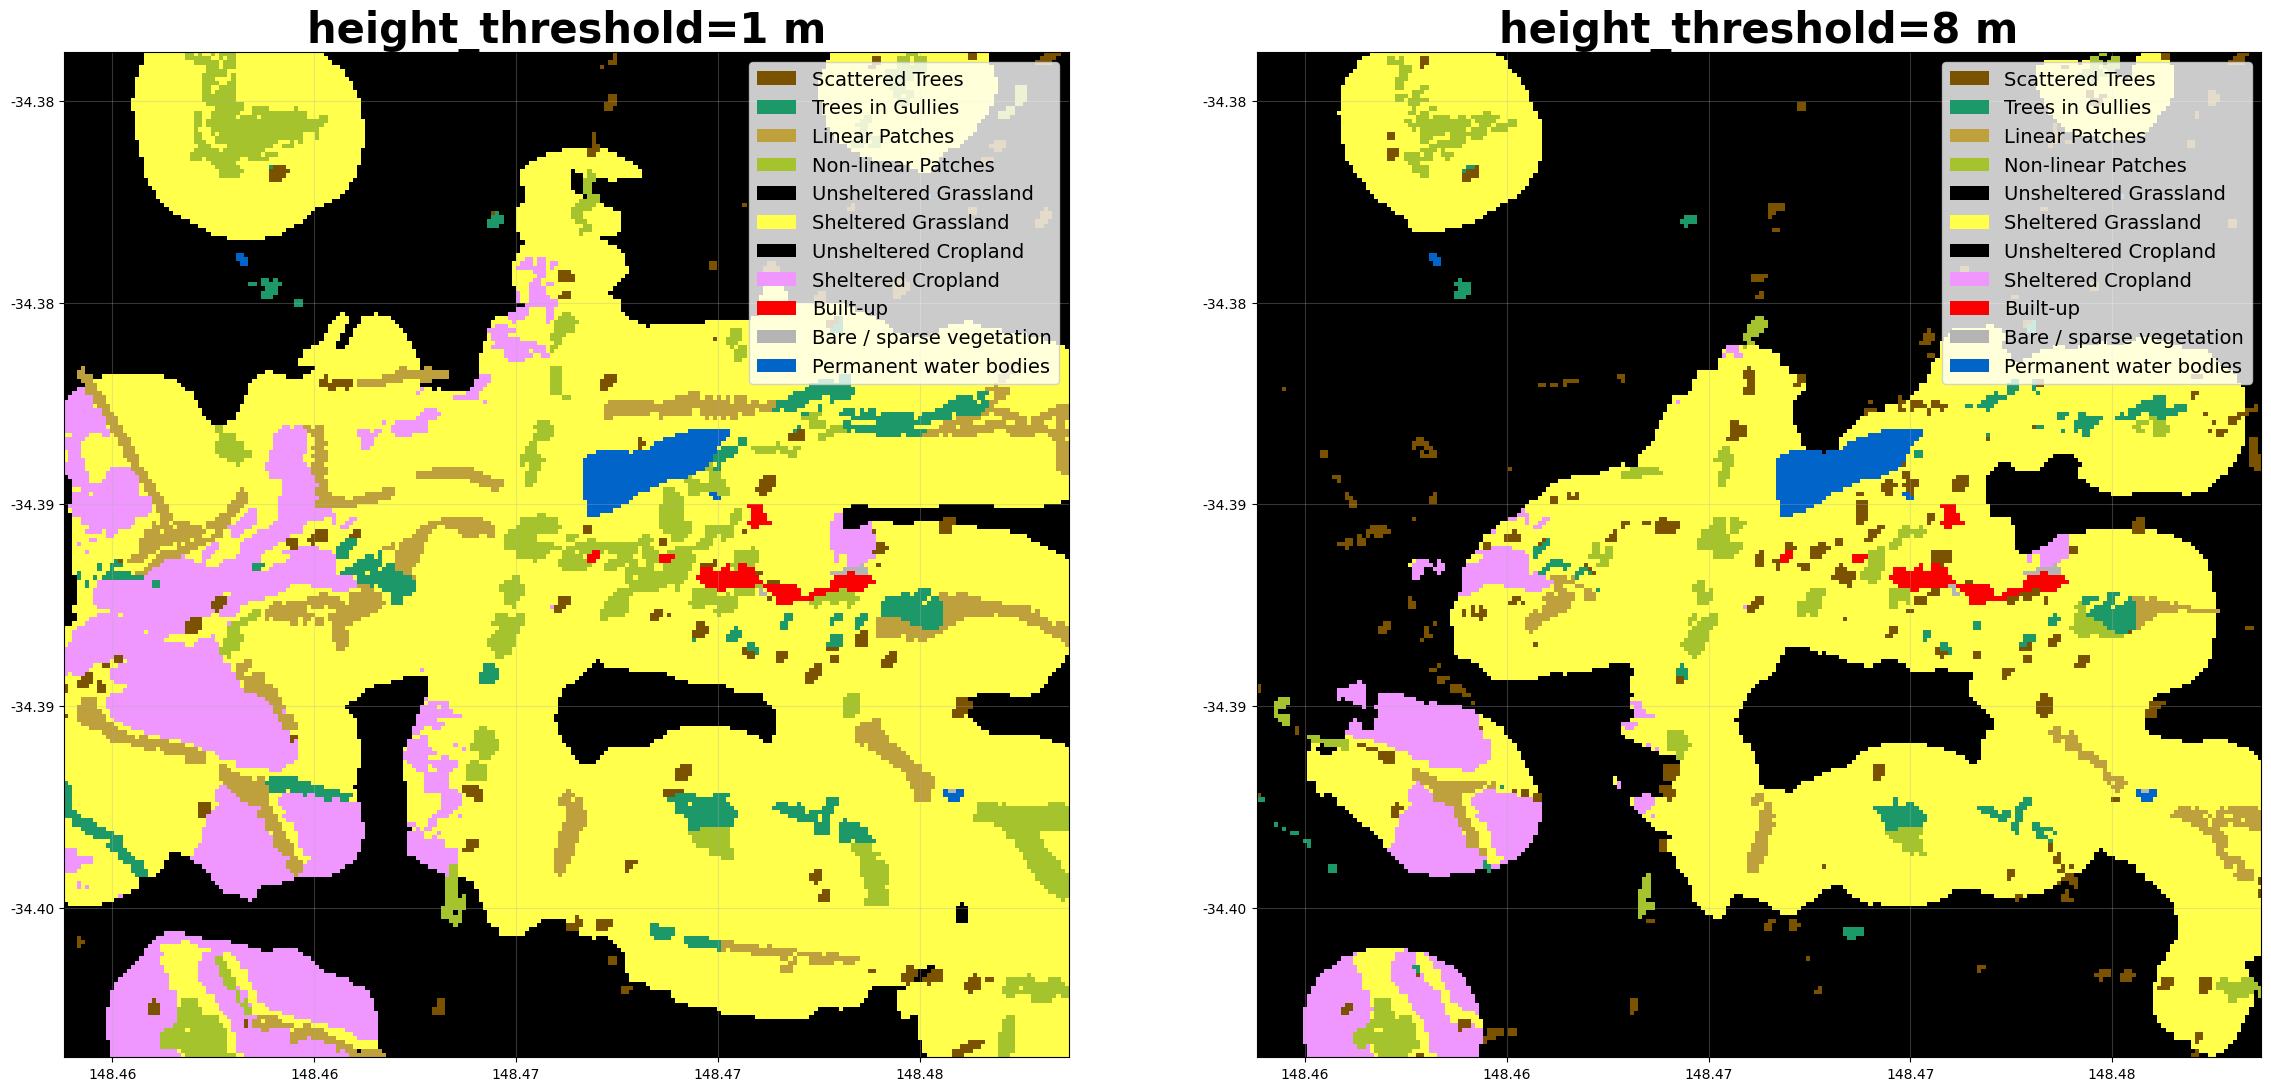

In [6]:
ds1, _ = indices_latlon(lat, lon, buffer, height_threshold=1.0, stub='height1')
ds2, _ = indices_latlon(lat, lon, buffer, height_threshold=8.0, stub='height8')
visualise_categories_sidebyside(
    ds1['linear_categories'], ds2['linear_categories'],
    colormap=linear_categories_cmap, labels=linear_categories_labels,
    title1="height_threshold=1 m", title2="height_threshold=8 m"
)

## Changing the cover_threshold

After resampling from 1 m to 10 m, each pixel holds the percentage of 1 m sub-pixels
that were classified as trees. `cover_threshold` sets the minimum percentage required
to count a 10 m pixel as a tree.

Working on 0/1: 3112302110
Merging 1 tiles
Saved: ./cover1_gullies.tif
Saved: ./cover1_linear_categories.tif
Working on 0/1: 3112302110
Merging 1 tiles
Saved: ./cover70_gullies.tif
Saved: ./cover70_linear_categories.tif


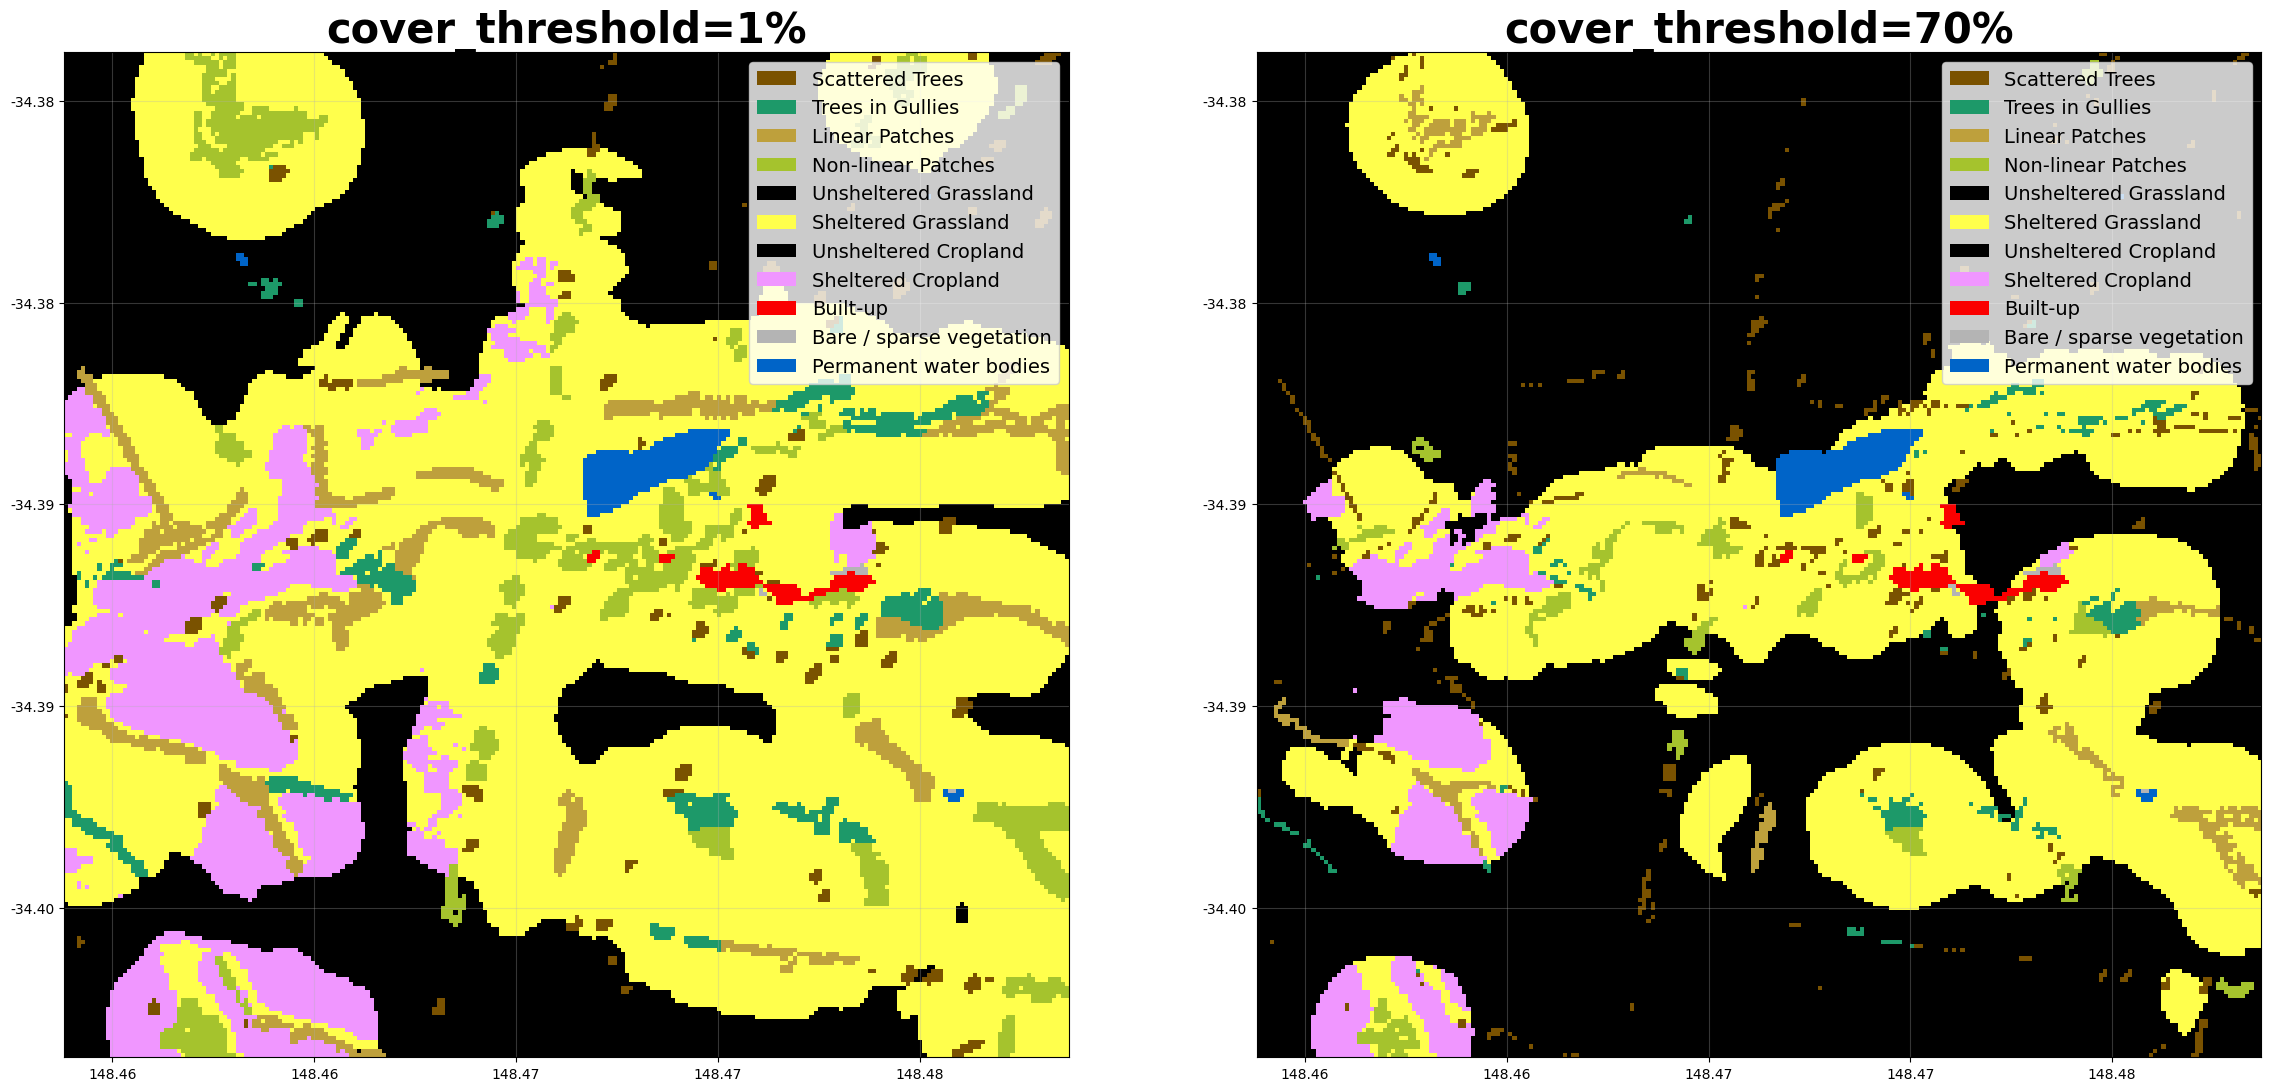

In [7]:
ds1, _ = indices_latlon(lat, lon, buffer, cover_threshold=1, stub='cover1')
ds2, _ = indices_latlon(lat, lon, buffer, cover_threshold=70, stub='cover70')
visualise_categories_sidebyside(
    ds1['linear_categories'], ds2['linear_categories'],
    colormap=linear_categories_cmap, labels=linear_categories_labels,
    title1="cover_threshold=1%", title2="cover_threshold=70%"
)

## Using Wind Data

Set `wind_method` to incorporate BARRA wind reanalysis data when determining shelter
direction. The wind data is automatically downloaded for the region.

- **MOST_COMMON**: shelter downwind of the most common strong-wind direction
- **WINDWARD**: shelter both downwind (full distance) and upwind (half distance)

Working on 0/1: 3112302110
Merging 1 tiles
Saved: ./wind_most_common_gullies.tif
Saved: ./wind_most_common_linear_categories.tif
Working on 0/1: 3112302110
Merging 1 tiles
Saved: ./wind_windward_gullies.tif
Saved: ./wind_windward_linear_categories.tif


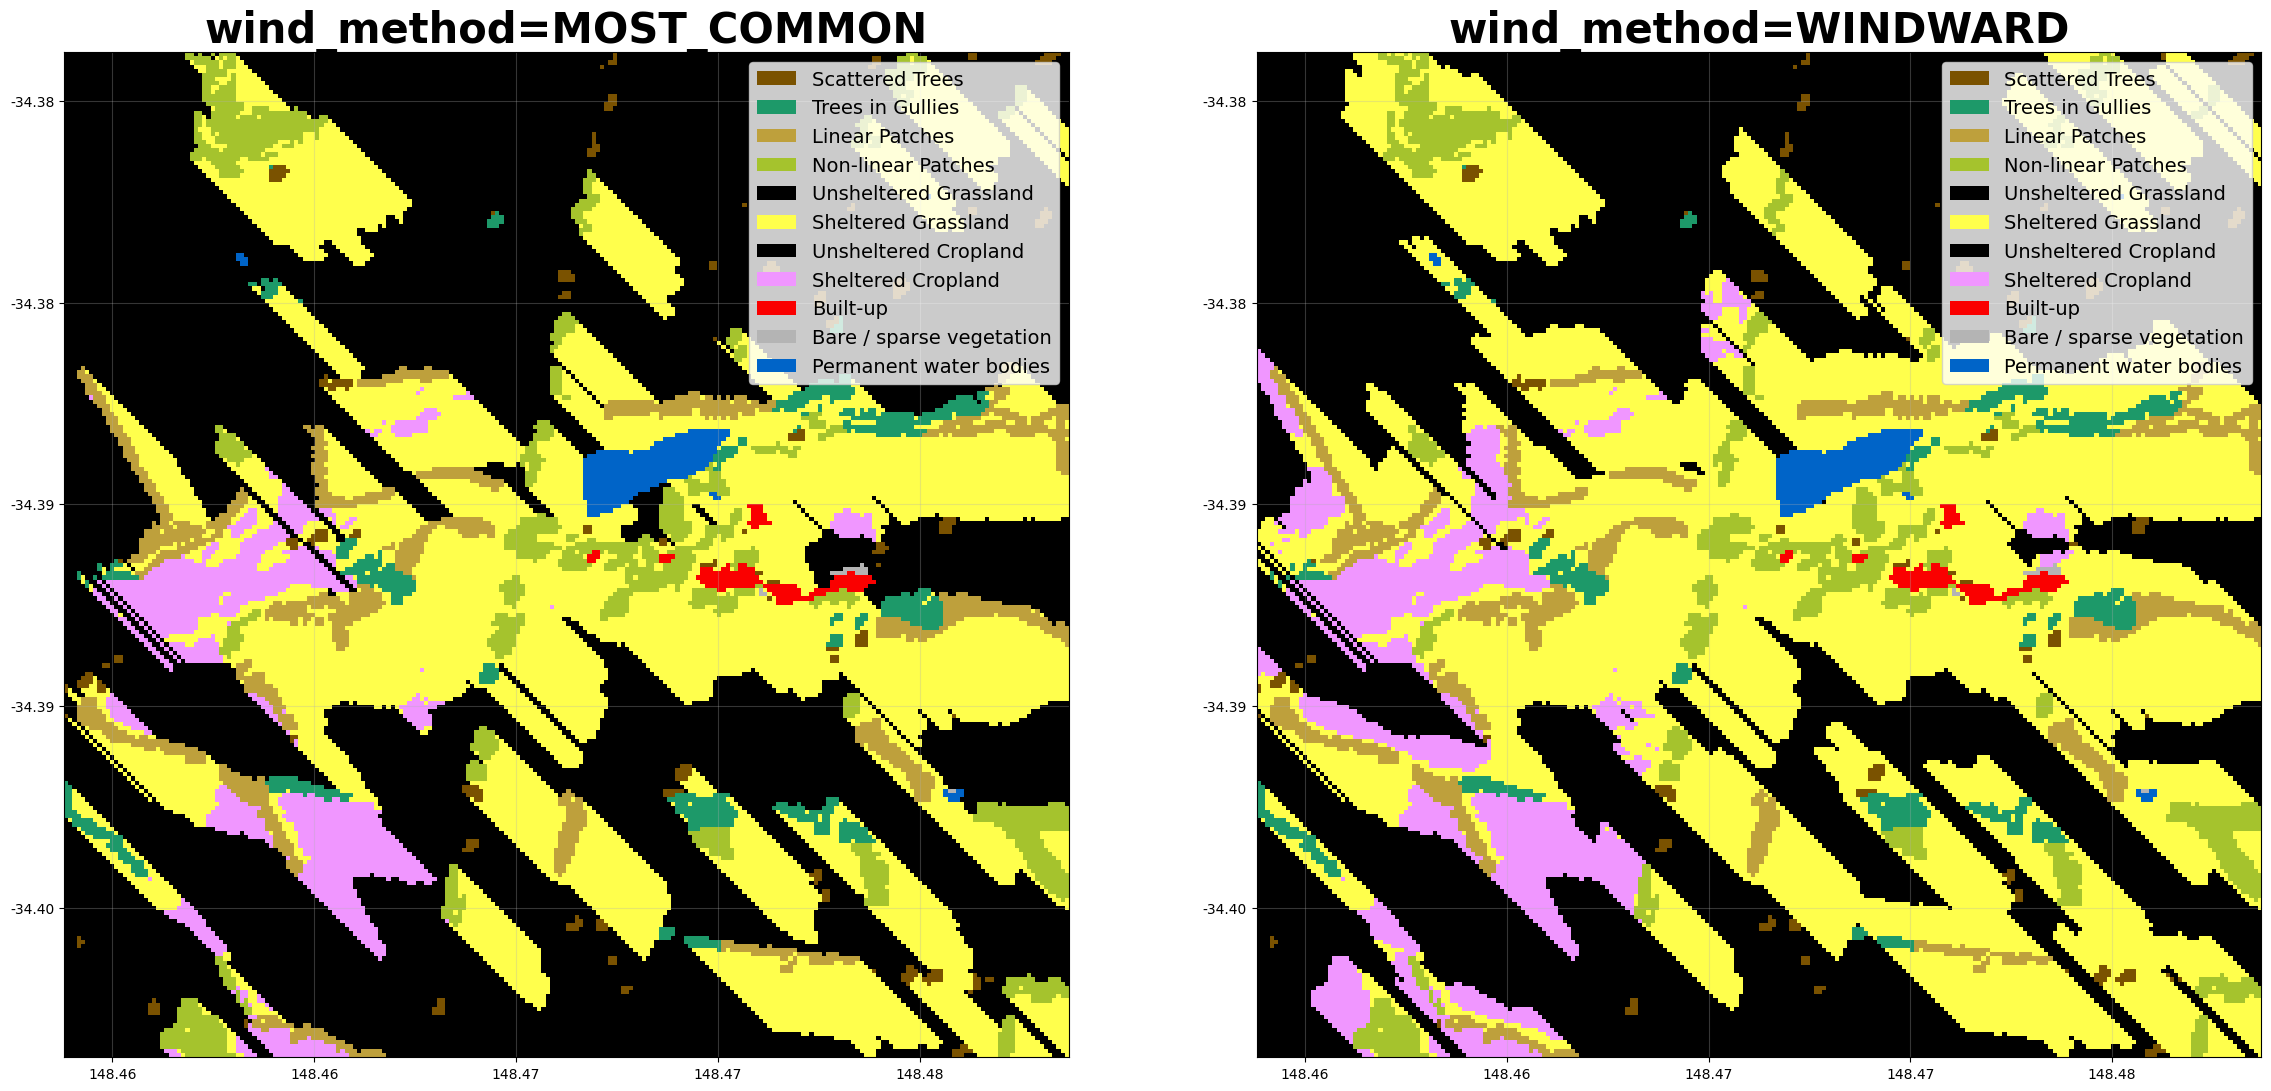

In [8]:
ds1, _ = indices_latlon(lat, lon, buffer, wind_method='MOST_COMMON', stub='wind_most_common')
ds2, _ = indices_latlon(lat, lon, buffer, wind_method='WINDWARD', stub='wind_windward')
visualise_categories_sidebyside(
    ds1['linear_categories'], ds2['linear_categories'],
    colormap=linear_categories_cmap, labels=linear_categories_labels,
    title1="wind_method=MOST_COMMON", title2="wind_method=WINDWARD"
)

### Cleanup
Remove output files created by this notebook

In [9]:
# !rm ./*.png
# !rm ./*.csv
# !rm ./*.xml  # Generated if tifs are opened in QGIS
# !rm ./*.gpkg
# !rm ./*.geojson

# # !rm ./*.tif # Double commenting this out by default so you don't have to redownload the 60MB chm.tif